#Plotting

1. Make sure you add axis labels and a legend (if necessary). Make sure your colors are easy to differentiate and that your font is large enough to easily read.

Hint: You may need to do some data restructuring/manipulation to create certain plots. The pandas `.melt()` and `.groupby()` methods may be helpful.

Reference: [Reshaping Tables With Pandas]( https://medium.com/towards-data-science/reshaping-data-with-pandas-ecff92572488 )

Read in the data located on AWS at [company_sales_data.csv]( https://ddc-datascience.s3.amazonaws.com/company_sales_data.csv )

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('https://ddc-datascience.s3.amazonaws.com/company_sales_data.csv')
df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600
5,6,2760,1555,4890,7490,1890,1555,20140,201400
6,7,2980,1120,4780,8980,1780,1120,29550,295500
7,8,3700,1400,5860,9960,2860,1400,36140,361400
8,9,3540,1780,6100,8100,2100,1780,23400,234000
9,10,1990,1890,8300,10300,2300,1890,26670,266700


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   month_number  12 non-null     int64
 1   facecream     12 non-null     int64
 2   facewash      12 non-null     int64
 3   toothpaste    12 non-null     int64
 4   bathingsoap   12 non-null     int64
 5   shampoo       12 non-null     int64
 6   moisturizer   12 non-null     int64
 7   total_units   12 non-null     int64
 8   total_profit  12 non-null     int64
dtypes: int64(9)
memory usage: 996.0 bytes


In [3]:
df.columns.to_list()

['month_number',
 'facecream',
 'facewash',
 'toothpaste',
 'bathingsoap',
 'shampoo',
 'moisturizer',
 'total_units',
 'total_profit']

##Matplotlib

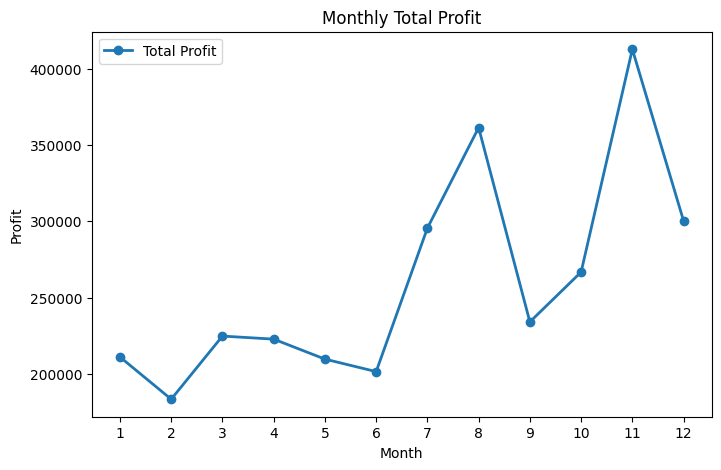

In [4]:
plt.figure(figsize=(8,5))

plt.plot(
  df['month_number'],
  df['total_profit'],
  marker='o',
  linewidth=2,
  label='Total Profit'
)

plt.title('Monthly Total Profit')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(df['month_number'])
plt.legend()

plt.show()

##Seaborn

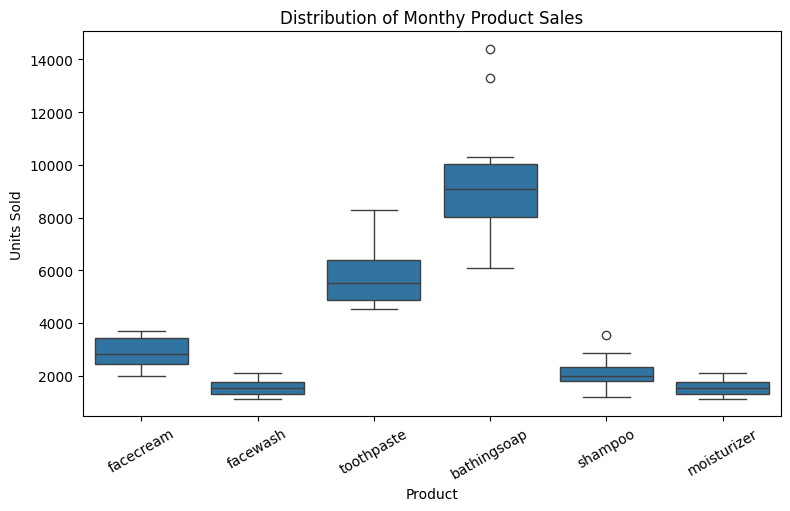

In [5]:
sales_long = df.melt(
  id_vars = 'month_number',
  value_vars = [
    'facecream',
    'facewash',
    'toothpaste',
    'bathingsoap',
    'shampoo',
    'moisturizer'
  ],
  var_name = 'Product',
  value_name = 'Sales'
)

plt.figure(figsize=(9,5))

sns.boxplot(
  data = sales_long,
  x = 'Product',
  y = 'Sales'
)

plt.title('Distribution of Monthy Product Sales')
plt.xlabel('Product')
plt.ylabel('Units Sold')

plt.xticks(rotation = 30)

plt.show()

##Plotly

In [10]:
fig = px.line(
  df,
  x = 'month_number',
  y = 'total_profit',
  title = 'Monthly Total Profit',
  markers = True,
  labels = {
    'month_number':'Month',
    'total_profit':'Total Profit'
  }
)

fig.update_traces(hovertemplate = '<b>Month %{x}</b><br>Total Profit: %{y}<extra></extra>')

fig.update_layout(
  xaxis = dict(rangeslider = dict(visible=True)),
  font = dict(size = 14),
  width = 900,
  height = 600
)

fig.show()